In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Input

In [3]:
df = pd.read_csv('google_stock_prices.csv')
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, shuffle=False)

In [ ]:
train_df = pd.read_csv('Google_Stock_Price_Train.csv')
test_df = pd.read_csv('Google_Stock_Price_Test.csv')

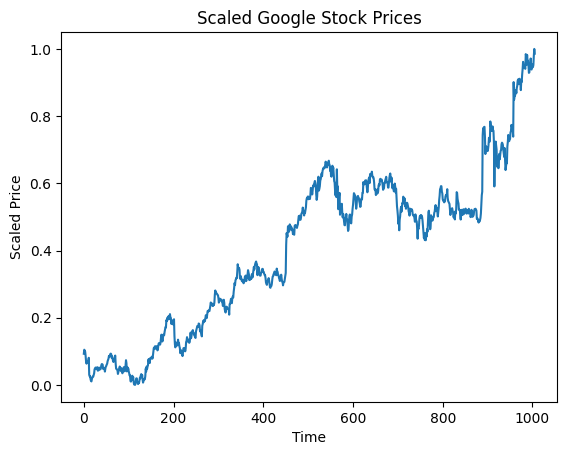

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[['Open']].values)

plt.plot(train_scaled)
plt.title("Scaled Google Stock Prices")
plt.xlabel("Time")
plt.ylabel("Scaled Price")
plt.show()

In [ ]:
time_step = 120 #use
x_train, y_train = [], []

for i in range(time_step, train_scaled.shape[0]):
    x_train.append(train_scaled[i-time_step:i, 0])
    y_train.append(train_scaled[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [6]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [7]:
model = Sequential([
    Input(shape=(x_train.shape[1], 1)),
    LSTM(100, activation='tanh', return_sequences=True), Dropout(0.3),
    LSTM(100, activation='tanh'), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 120, 100)            │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 120, 100)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100)                 │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(x_train, y_train, epochs=20, batch_size=50, validation_split=0.05)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 268ms/step - loss: 0.0350 - val_loss: 0.0329
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - loss: 0.0388 - val_loss: 0.0192
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - loss: 0.0348 - val_loss: 0.0192
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - loss: 0.0317 - val_loss: 0.0190
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step - loss: 0.0334 - val_loss: 0.0300
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - loss: 0.0344 - val_loss: 0.0451
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step - loss: 0.0343 - val_loss: 0.0753
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step - loss: 0.0337 - val_loss: 0.0740
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step - loss: 0.0354 - val_loss: 0.0597
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - loss: 0.0312 - val_loss: 0.0463
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - loss: 0.0338 - val_loss: 0.0367
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step

In [10]:
data = pd.concat((train_df['Open'], test_df['Open']), axis=0)
test_input = data[len(data) - len(test_df) - time_step:].values.reshape(-1, 1)

test_scaled = scaler.transform(test_input)

In [11]:
x_test = []
for i in range(time_step, test_scaled.shape[0]):
    x_test.append(test_scaled[i-time_step:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [12]:
y_pred = model.predict(x_test)
y_pred = scaler.inverse_transform(y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step


In [13]:
y_test = test_df['Open'].values
output = model.evaluate(x_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 742.8484


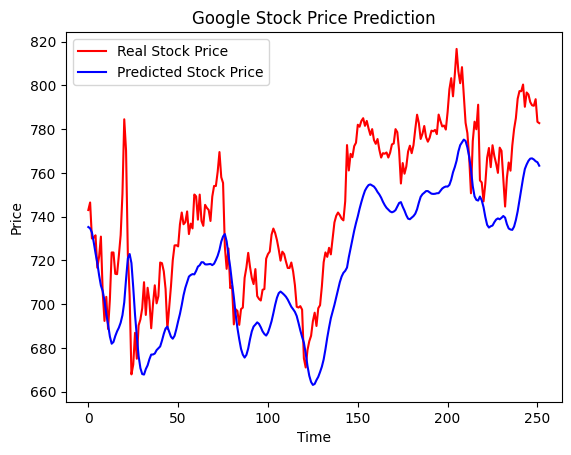

In [14]:
plt.plot(y_test, color='red', label='Real Stock Price')
plt.plot(y_pred, color='blue', label='Predicted Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()